#### Configuration

In [ ]:
import os
import pickle
from methyldl.deconvolution.xgbdeconvolver import *
from tqdm import tqdm
from collections import defaultdict
import torch.nn as nn
from copy import deepcopy
from methyldl.deconvolution.deep_deconvolvers.training import train_matrix_deconvolver
import os.path as Path
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
from edautils import *

reads_data_path = "/home/luna.kuleuven.be/u0169940/Data/Loyfer/SoftLabelsTrainingData_hg38_mincpg_4_minlen_10/"
dmr_label_column = "dmr_ctype_label"
mincpg_pointer = reads_data_path.find("mincpg_")
# classifier_model_path = f"../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_{dmr_label_column}_{reads_data_path[mincpg_pointer:]}"
classifier_model_path = "../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels"
mincpg = int(reads_data_path[mincpg_pointer + 7 : mincpg_pointer + 8])
features_encoding = "extracted_numpy"

#### Determining informative features

In [3]:
with open("soft_labels_pure_ios.pkl", "rb") as f:
    soft_labels_pure_ios = pickle.load(f)

In [4]:
target_columns = [f"prediction_{i}_wavg" for i in range(39)]

In [5]:
pure_train = np.array(
    [soft_labels_pure_ios[i][1][0][target_columns].to_numpy() for i in range(39)]
)
pure_valid = np.array(
    [soft_labels_pure_ios[i][1][1][target_columns].to_numpy() for i in range(39)]
)
pure_test = np.array(
    [soft_labels_pure_ios[i][1][2][target_columns].to_numpy() for i in range(39)]
)

In [6]:
pure_train_ratios = pure_train.max(axis=(0)) / pure_train.mean(axis=(0))
pure_valid_ratios = pure_valid.max(axis=(0)) / pure_valid.mean(axis=(0))
pure_test_ratios = pure_test.max(axis=(0)) / pure_test.mean(axis=(0))

In [7]:
maximal_ratios = np.array([pure_train_ratios, pure_valid_ratios, pure_test_ratios]).max(
    axis=(0)
)

Number of features with selected cutoff 1.1: 152 from 1521


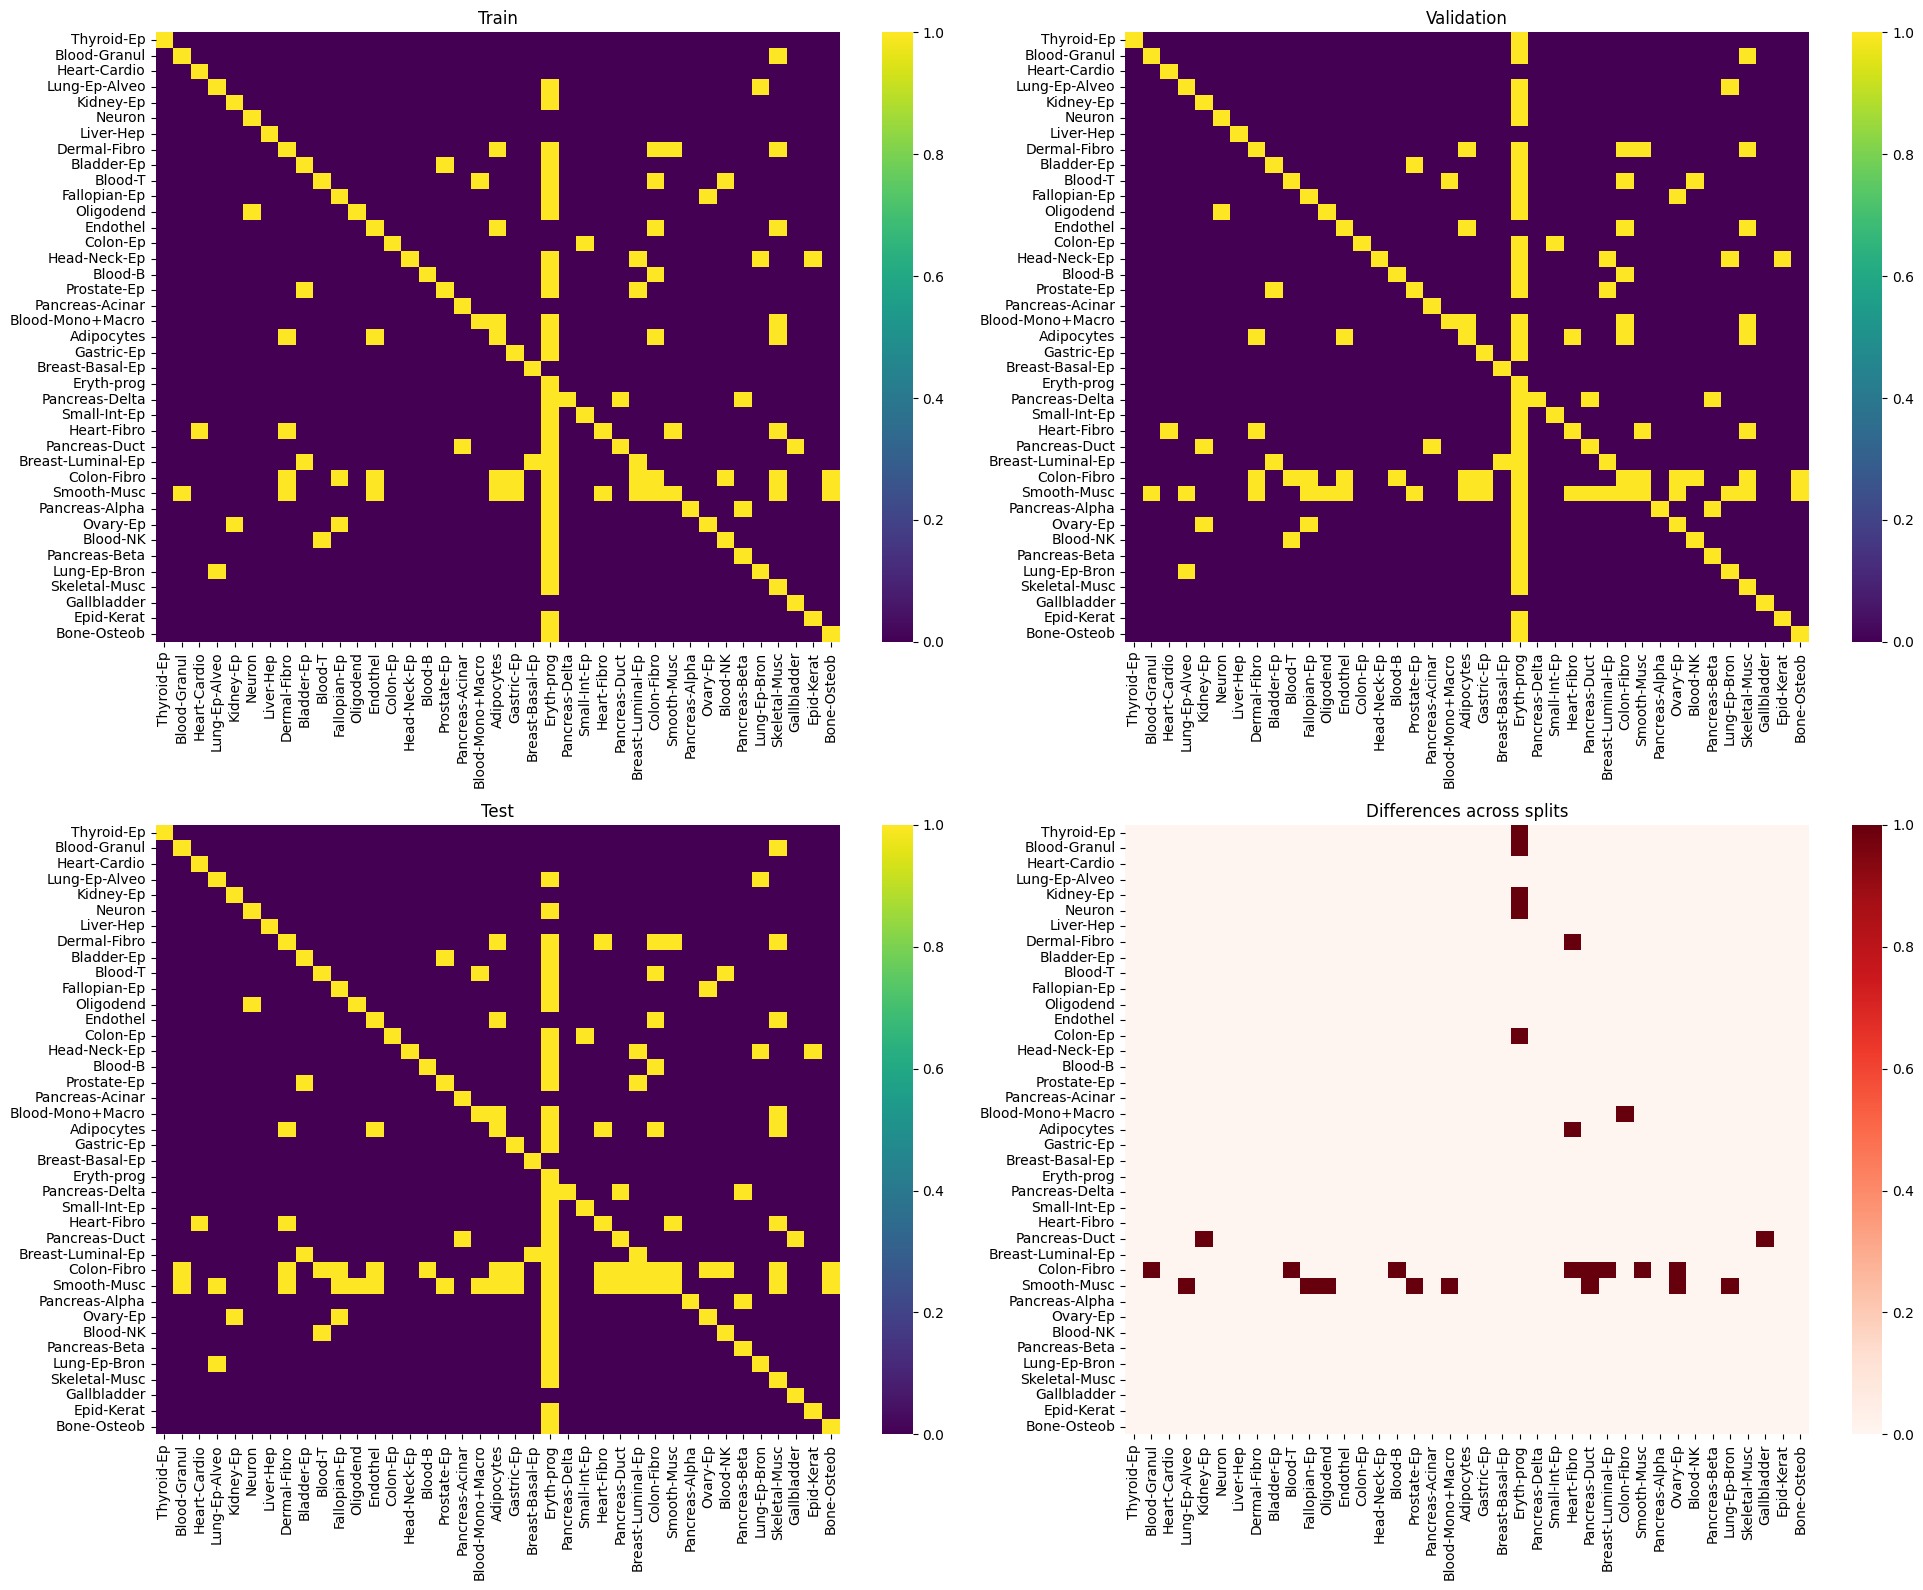

In [8]:
cutoff = 1.1
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

master_names = soft_labels_pure_ios[0][1][0]["dmr_ctype"]
heatmap_kwargs = {
    "cmap": "viridis",
    "yticklabels": master_names,
    "xticklabels": master_names,
}

# Binary masks
train_bin = (pure_train_ratios > cutoff).astype(int)
valid_bin = (pure_valid_ratios > cutoff).astype(int)
test_bin = (pure_test_ratios > cutoff).astype(int)
maximal_bin = (maximal_ratios > cutoff).astype(int)
# "Fires" wherever not all three agree
diff_mask = ~((train_bin == valid_bin) & (valid_bin == test_bin))

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

print(
    f"Number of features with selected cutoff {cutoff}: {np.sum(maximal_bin)} from {39*39}"
)

sns.heatmap(train_bin, ax=axes[0, 0], **heatmap_kwargs)
axes[0, 0].set_title("Train")

sns.heatmap(valid_bin, ax=axes[0, 1], **heatmap_kwargs)
axes[0, 1].set_title("Validation")

sns.heatmap(test_bin, ax=axes[1, 0], **heatmap_kwargs)
axes[1, 0].set_title("Test")

sns.heatmap(
    diff_mask,
    ax=axes[1, 1],
    cmap="Reds",
    yticklabels=master_names,
    xticklabels=master_names,
)
axes[1, 1].set_title("Differences across splits")

plt.tight_layout()
plt.show()

#### Extract features from IOs

In [9]:
def _extract_diag_and_rej(matrix):
    return np.reshape(np.concat([np.diag(matrix), matrix[:, -1]], axis=0), (1, 78))


def _extract_features_by_mask(matrix, target_mask):
    return np.expand_dims(
        np.ma.masked_array(matrix, ~np.array(target_mask, dtype=np.bool)).compressed(),
        0,
    )

In [ ]:
# np.savez_compressed(os.path.join(classifier_model_path, 'features_mask_1.1_cutoff.npz'), features_mask = maximal_bin)

In [ ]:
proportions_list = []
features_train_list = []
features_valid_list = []
features_test_list = []
pred_cols = [f"prediction_{i}_wavg" for i in range(39)]

for ios in tqdm(os.listdir(os.path.join(classifier_model_path, "ios_deconvolution"))):
    try:
        with open(
            os.path.join(classifier_model_path, "ios_deconvolution", ios), "rb"
        ) as f:
            part_ios = pickle.load(f)
    except:
        Warning(f"{ios} file is corrupted and cannot be opened")
    for i in range(len(part_ios)):
        gt = np.reshape(part_ios[i][0], (1, 39))
        # f_tr = _extract_features_by_mask(part_ios[i][1][0][pred_cols].to_numpy(),maximal_bin)
        # f_val = _extract_features_by_mask(part_ios[i][1][1][pred_cols].to_numpy(),maximal_bin)
        # f_tst = _extract_features_by_mask(part_ios[i][1][2][pred_cols].to_numpy(),maximal_bin)

        f_tr = np.expand_dims(part_ios[i][1][0][pred_cols].to_numpy(), 0)
        f_val = np.expand_dims(part_ios[i][1][1][pred_cols].to_numpy(), 0)
        f_tst = np.expand_dims(part_ios[i][1][2][pred_cols].to_numpy(), 0)

        features_train_list.append(f_tr)
        features_valid_list.append(f_val)
        features_test_list.append(f_tst)
        proportions_list.append(gt)

# Single concatenation at the end (O(n))
proportions = np.concatenate(proportions_list, axis=0)
features_train = np.concatenate(features_train_list, axis=0)
features_valid = np.concatenate(features_valid_list, axis=0)
features_test = np.concatenate(features_test_list, axis=0)

100%|██████████| 100/100 [07:06<00:00,  4.26s/it]


In [21]:
np.savez_compressed(
    os.path.join(classifier_model_path, "ios_full_matrices.npz"),
    proportions=proportions,
    features_train=features_train,
    features_valid=features_valid,
    features_test=features_test,
)

(3900000, 39)

#### Train the model

In [10]:
model_checkpoint = [x for x in os.listdir(classifier_model_path) if "checkpoint" in x][
    0
]
fine_tuned_model_path = os.path.join(
    classifier_model_path, model_checkpoint, "model.safetensors"
)

In [11]:
with open(
    f"{classifier_model_path}/methylbert_deconv_prepared_splits_hg38_uxm_ready_with_predictions.pkl",
    "rb",
) as f:
    train_split_uxm_input, valid_split_uxm_input, test_split_uxm_input = pickle.load(f)

In [12]:
if features_encoding != "extracted_numpy":
    with open(
        f"{classifier_model_path}/ios_deconvolution_data_hg38_grouped_dmrs_uxm_alligned.pkl",
        "rb",
    ) as f:
        all_ios = pickle.load(f)
    train_features = np.array(
        [
            np.array(all_ios[k][1][0][[f"prediction_{i}_wavg" for i in range(40)]])
            for k in range(len(all_ios))
        ]
    )
    valid_features = np.array(
        [
            np.array(all_ios[k][1][1][[f"prediction_{i}_wavg" for i in range(40)]])
            for k in range(len(all_ios))
        ]
    )
    test_features = np.array(
        [
            np.array(all_ios[k][1][2][[f"prediction_{i}_wavg" for i in range(40)]])
            for k in range(len(all_ios))
        ]
    )
    train_outputs = valid_outputs = test_outputs = np.array(
        [np.array(all_ios[k][0]) for k in range(len(all_ios))]
    )
else:
    data = np.load(os.path.join(classifier_model_path, "features_1.1_cutoff.npz"))
    train_features = data["features_train"]
    valid_features = data["features_valid"]
    test_features = data["features_test"]
    train_outputs = valid_outputs = test_outputs = data["proportions"]

In [13]:
cell_types_map = train_split_uxm_input[
    ["dmr_ctype_label", "dmr_ctype"]
].drop_duplicates()

In [14]:
labels_dict = {
    x: y
    for (x, y) in zip(cell_types_map["dmr_ctype_label"], cell_types_map["dmr_ctype"])
}
labels_dict = dict(sorted(labels_dict.items()))
labels_dict_reversed = {y: x for (x, y) in labels_dict.items()}

In [15]:
len(valid_features)

100000

In [16]:
def train_xgb_deconvolver(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    config: Optional[XGBDeconvolverConfig] = None,
    n_dmr_groups=39,
    n_pred_classes=40,
    n_cell_types=39,
    with_reject_features=True,
    process_inputs=True,
    output_transform: Literal["none", "clip_normalize", "softmax"] = "clip_normalize",
    loss_weights: Optional[Dict[str, float]] = None,
    early_stopping_metric: str = "val_mae",
    early_stopping_patience: int = 15,
    verbose: int = 1,
) -> tuple:
    """
    Convenience function matching the signature pattern of train_matrix_deconvolver.

    Returns
    -------
    model : XGBoostDeconvolver
        Trained model
    history : XGBTrainingHistory
        Training history
    """
    if config is None:
        config = XGBDeconvolverConfig(early_stopping_rounds=early_stopping_patience)

    model = XGBoostDeconvolver(
        config=config,
        output_transform=output_transform,
        n_dmr_groups=n_dmr_groups,
        n_pred_classes=n_pred_classes,
        n_cell_types=n_cell_types,
        with_reject_features=with_reject_features,
        process_inputs=process_inputs,
    )

    model.fit(
        X_train,
        y_train,
        X_val,
        y_val,
        loss_weights=loss_weights,
        early_stopping_metric=early_stopping_metric,
        verbose=verbose,
    )

    return model, model.history

In [17]:
config = XGBDeconvolverConfig(
    n_estimators=500,
    max_depth=15,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=1,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=100,
    random_state=42,
)

# Train with metrics
xgb_model, history = train_xgb_deconvolver(
    train_features,
    train_outputs,
    valid_features,
    valid_outputs,
    config=config,
    n_pred_classes=39,
    output_transform="clip_normalize",
    early_stopping_metric="val_mae",
    verbose=1,
    process_inputs=False,
    with_reject_features=False,
    loss_weights={"mse_weight": 1.0, "kl_weight": 0.5},
)

# xgb_model, history = train_xgb_deconvolver(
#     np.concatenate([train_features, valid_features, test_features]), np.concatenate([train_outputs, valid_outputs, test_outputs]),
#     valid_features, valid_outputs,
#     config=config,
#     output_transform='clip_normalize',
#     early_stopping_metric='val_mae',
#     verbose=1,
#     loss_weights = {'mse_weight': 1.0, 'kl_weight': 5}
# )

Training XGBoost Deconvolver
  Input shape: (100000, 152) → Features: (100000, 152)
  Output shape: (100000, 39)
  Output transform: clip_normalize
  Early stopping on: val_mae
------------------------------------------------------------

Training Results:
  Train Loss: 0.0013
  Train MAE:  0.0003
  Train MSE:  0.0000
  Train KL:   0.0027
  Train Max Error: 0.0537
  Train Cosine Sim: 0.9999

Validation Results:
  Val Loss:   0.0391
  Val MAE:    0.0043
  Val MSE:    0.0003
  Val KL:     0.0777
  Val Max Error: 0.5476
  Val Cosine Sim: 0.9881


In [18]:
classifier_model_path

'../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels'

In [19]:
xgb_model.save(f"{classifier_model_path}/xgb_dpth15.pt")

Model saved to ../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels/xgb_dpth15.pt


In [ ]:
mlp_deep = nn.Sequential(
    nn.Linear(152, 1024),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(1024, 39),
    nn.Softmax(dim=-1),
)

mlp3l = nn.Sequential(
    nn.Linear(152, 512),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(256, 152),
    nn.GELU(),
    nn.Dropout(0.1),
    nn.Linear(152, 39),
    nn.Softmax(dim=-1),
)

In [ ]:
classifier_model_path + "3LMLP_best_deconvolver.pt"

In [ ]:
mlp3l.load_state_dict(
    torch.load(classifier_model_path + "3LMLP_best_deconvolver.pt", weights_only=True)
)

In [ ]:
mode = "inference"

# Initialize model
# diagd = DiagonalAwareDeconvolver(n_dmr_groups=39, n_pred_classes=40, n_cell_types=39,use_confusion=False)
model_pairs = zip([mlp3l], ["mlp"])
early_stopping_metric = "val_mse"

In [ ]:
if mode == "training":
    histories = defaultdict(list)
    for model, model_name in model_pairs:
        # Train with early stopping on MAE
        model, history = train_matrix_deconvolver(
            model=model,
            X_train=train_features,
            y_train=train_outputs,
            X_val=valid_features,
            y_val=valid_outputs,
            n_epochs=10000,
            batch_size=500,
            lr=0.5 * 1e-4,
            weight_decay=1e-3,
            device="cuda",
            early_stopping_metric=early_stopping_metric,  # or 'val_loss', 'val_cosine_sim', etc.
            early_stopping_patience=3000,  # n_epochs == patience --> no early stopping
            early_stopping_min_delta=1e-5,
            scheduler_type=None,
            loss_weights={"mse": 1.0, "kl": 0.5},
            verbose=1,
            save_path=f"deconvolution_models/{model_name}_best_deconvolver.pt",
        )
        histories[model_name] = history
        # Access history
        print(f"Stopped early: {history.stopped_early}")
        print(f"Best epoch: {history.best_epoch + 1}")
        print(f"Final val MAE: {history.val_mae[history.best_epoch]:.4f}")
elif mode == "inference":
    device = "cuda"
    test_loader = DataLoader(
        TensorDataset(
            torch.FloatTensor(test_features), torch.FloatTensor(test_outputs)
        ),
        batch_size=2000,
    )
    results = defaultdict(tuple)
    for model, model_name in model_pairs:
        model.to(device)
        model.load_state_dict(
            torch.load(
                f"deconvolution_models/{model_name}_best_deconvolver.pt",
                weights_only=True,
            )
        )
        model.eval()

        all_preds = []
        all_targets = []

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)

                all_preds.append(pred.cpu())
                all_targets.append(y.cpu())

        # Compute all metrics
        all_preds = torch.cat(all_preds, dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        metrics = compute_deconvolution_metrics(all_preds, all_targets)
        all_targets = all_targets.numpy()
        all_preds = np.round(all_preds.numpy(), 4)

        results[model_name] = (all_targets, all_preds, metrics)
        try:
            fig, all_metrics = plot_deconvolution_results(
                y_true=all_targets,
                y_pred=all_preds,
                labels_dict=labels_dict,
                figsize=(22, 10),
                zero_threshold=0.0001,
                save_path=f"plots/{model_name}_loyfer_test_resuts.png",
                alpha=0.4,
                point_size=12,
            )
        except:
            pass

In [ ]:
# all_preds = xgb_model._predict_raw(test_features)
# all_preds = xgb_model._transform_output(test_features)

In [ ]:
all_targets = train_outputs
all_preds = np.array(xgb_model._transform_output(xgb_model._predict_raw(test_features)))

In [ ]:
fig, all_metrics = plot_deconvolution_results(
    y_true=all_targets,
    y_pred=all_preds,
    labels_dict=labels_dict,
    figsize=(22, 10),
    zero_threshold=0.0001,
    save_path="deconvolution_results.png",
    alpha=0.4,
    point_size=12,
)

# Print summary
print_deconvolution_metrics_summary(all_metrics)

In [ ]:
fig, all_metrics = plot_deconvolution_results(
    y_true=all_targets,
    y_pred=all_preds,
    labels_dict=labels_dict,
    figsize=(22, 10),
    zero_threshold=0.0001,
    save_path="deconvolution_results.png",
    alpha=0.4,
    point_size=12,
)

# Print summary
print_deconvolution_metrics_summary(all_metrics)

In [ ]:
with open("../inference_output/dmr_aggregated.pkl", "rb") as f:
    x = pickle.load(f)

In [ ]:
with open("wgbs_bsbolt_parsed_with_uxm_results.pkl", "rb") as f:
    results, uxm_res_dict = pickle.load(f)

In [ ]:
from methyldl.modelling.classifiers.methylbert import (
    MethylVocab,
    MethylBertFinetuneDataset,
)
from methyldl.data.sequencing.genome import generate_kmer_str_with_overlap
from methyldl.data import CELL_TYPE_MATCH_DICT as cell_type_match_dict
from methyldl.modelling.classifiers.methylbert import (
    MethylBert,
    default_methylbert_config,
)

In [ ]:
dmr_label_column = "dmr_ctype_label"
seq_length = 150
dmrs = pd.DataFrame(
    pd.concat(
        [
            pd.read_parquet(reads_data_path + f"/{split}.parquet")
            for split in ["train", "valid", "test"]
        ]
    )[dmr_label_column].unique()
)
dmrs.columns = [dmr_label_column]

In [ ]:
from collections import OrderedDict

model_instance = MethylBert(
    custom_config=rrms_config,
    foundation_model_path="hanyangii/methylbert_hg19_12l",
    num_labels=39,
    num_dmr_labels=max(dmrs[dmr_label_column]) + 1,
    fine_tuned_model_path=fine_tuned_model_path,
    classifier_implementation="dmr_attention_based",
)

In [ ]:
def generate_valid_tokens(read_data, k=3):
    """
    Yields valid k-mers and their ORIGINAL indices.
    Skips any k-mer containing 'N'.
    """
    seq = read_data["input_ids"]
    pattern = read_data["methylation_ids"]

    # We iterate up to len(seq) - k + 1
    for i in range(len(seq) - k + 1):
        kmer = seq[i : i + k]

        # 1. Check for 'N' in the window
        if "N" in kmer:
            continue

        center_idx = i + 1
        methylation_code = pattern[center_idx]

        # Yield the clean k-mer and its specific methylation label
        yield [kmer, methylation_code]

In [ ]:
def chunk_tokens(tokens, window_size, stride):
    """
    Splits a list of tokens into overlapping chunks of fixed size.
    Ensures no chunk is shorter than window_size (unless the total read is shorter).
    """
    total_len = len(tokens)

    # Case 1: Read is shorter than the window. Return as is.
    if total_len <= window_size:
        yield tokens
        return

    # Case 2: Sliding window
    # We iterate until the window would go out of bounds
    for i in range(0, total_len - window_size + 1, stride):
        yield tokens[i : i + window_size]

    # Case 3: Handle the "Tail"
    # If the last sliding window didn't exactly align with the end,
    # we yield one final chunk containing the *last* window_size elements.
    # This creates a variable overlap for the last segment, but ensures full context.
    if total_len % stride != 0:
        yield tokens[-window_size:]


def prepare_methylbert_list_inference(
    results_df, dmr_label_column, seq_length=150, stride=75
):
    """
    Prepares inference data with sliding window chunking.
    params:
        stride: How far to move the window (75 = 50% overlap for 150bp window)
    """
    data_list = [
        [
            "dna_seq",
            "methyl_seq",
            "dmr_ctype",
            "dmr_label",
            "ctype",
            "original_label",
            "read_name",
            "ncpgs_marked",
        ]
    ]

    for i, row in results_df.iterrows():
        # 1. Get the CLEAN stream of tokens (Ns removed)
        processed_read_full = list(generate_valid_tokens(row))
        read_name = row["read_name"]
        # If read was entirely Ns or empty, skip
        if not processed_read_full:
            continue

        # 2. Chunk the valid tokens
        # We process the read in chunks of 'seq_length'
        for chunk in chunk_tokens(
            processed_read_full, window_size=seq_length, stride=stride
        ):

            dna = " ".join([x[0] for x in chunk])
            methyl = "".join([x[1] for x in chunk])
            ncpgs_marked = methyl.count("0") + methyl.count("1")
            # Metadata propagation
            # Note: You might want to track which chunk this is (e.g., read_id_0, read_id_1)
            # but for bulk inference, this format works.
            label = 0
            o_label = 0
            dmr_label = row[dmr_label_column]
            dmr_ctype = row["dmr_ctype_label"]

            data_list.append(
                [
                    dna,
                    methyl,
                    dmr_ctype,
                    dmr_label,
                    label,
                    o_label,
                    read_name,
                    ncpgs_marked,
                ]
            )

    return data_list

In [ ]:
results.rename(columns={"seq": "input_ids", "pattern": "methylation_ids"}, inplace=True)
results_for_methylbert = results[results["pattern_len"] >= 3]
out_of_bag_test = prepare_methylbert_list_inference(
    results_for_methylbert, dmr_label_column=dmr_label_column, seq_length=seq_length
)

In [ ]:
out_of_bag_dataset = MethylBertFinetuneDataset(
    data_source=out_of_bag_test,
    vocab=MethylVocab(k=3),
    seq_len=seq_length,
    lazy_tokenization=True,
)
out_of_bag_predicitons = model_instance.predict(out_of_bag_dataset, batch_size=2200)
# results_for_methylbert = pd.concat([results_for_methylbert.reset_index(), out_of_bag_predicitons_pd.reset_index()],axis=1)
# results_for_methylbert.rename(columns={"methylated_cpgs":"methylated_CpGs",
#                            "unmethylated_cpgs":"unmethylated_CpGs",
#                            "methylation_rate":"methylation_level"}, inplace=True)
out_of_bag_predicitons_pd = pd.DataFrame(
    out_of_bag_predicitons[0], columns=["prediction_" + str(x) for x in range(39)]
)
out_of_bag_predicitons_pd["read_name"] = [x[-3] for x in out_of_bag_test[1:]]
out_of_bag_predicitons_pd["ncpgs_marked"] = [x[-2] for x in out_of_bag_test[1:]]

In [ ]:
def aggregate_predictions_weighted(
    pred_df, weight_col="ncpgs_marked", group_col="read_name"
):
    """
    Calculates the weighted average of prediction columns grouped by read_name.
    """
    # 1. Identify prediction columns (prediction_0 ... prediction_39)
    pred_cols = [c for c in pred_df.columns if c.startswith("prediction_")]

    # 2. Create a working copy to avoid SettingWithCopy warnings
    df = pred_df.copy()

    # 3. Vectorized Weighting: Multiply all prediction columns by the weight column
    # This is much faster than doing it inside the groupby
    df[pred_cols] = df[pred_cols].multiply(df[weight_col], axis=0)

    # 4. Group by read_name and sum both the weighted predictions and the weights
    grouped = df.groupby(group_col)

    # Sum the weighted scores
    summed_preds = grouped[pred_cols].sum()

    # Sum the weights (the total number of CpGs seen across all chunks for this read)
    summed_weights = grouped[weight_col].sum()

    # 5. Divide to get the Weighted Average
    # We use .div with axis=0 to align by the index (read_name)
    final_averaged_df = summed_preds.div(summed_weights, axis=0)

    # 6. Cleanup
    # Handle cases where total weight might be 0 (avoid division by zero errors)
    # Though your filtering likely prevents this, it's good practice.
    final_averaged_df = final_averaged_df.fillna(0)

    # Reset index so 'read_name' becomes a column again
    return final_averaged_df.reset_index()

In [ ]:
out_of_bag_predicitons_pd = aggregate_predictions_weighted(out_of_bag_predicitons_pd)
results_for_methylbert = pd.merge(
    results_for_methylbert, out_of_bag_predicitons_pd, on="read_name"
).dropna()

In [ ]:
# with open(f"{classifier_model_path}/encode_adipocytes_predictions.pkl", "wb") as f:
#     pickle.dump(results_for_methylbert,f)

In [ ]:
with open(f"{classifier_model_path}/encode_adipocytes_predictions.pkl", "rb") as f:
    results_for_methylbert = pickle.load(f)

In [ ]:
results_for_methylbert.dropna(inplace=True)
results_for_methylbert.rename(columns={"M_rate": "methylation_level"}, inplace=True)

In [ ]:
def sample_bulk(total_samples, data):
    res = defaultdict(lambda: pd.DataFrame)
    grouped = data.groupby(["file", "dmr_ctype_label"], sort=False)
    for file in [str(x) for x in data["file"].unique()]:
        sub = []
        for dmr_ctype_label in range(39):
            try:
                group = grouped.get_group((file, dmr_ctype_label))
            except:
                print(
                    f"{(file,dmr_ctype_label)} is absent from the data and will be not included into samples"
                )
            sub.append(group.sample(int(total_samples / 39), replace=True))
        sub = pd.concat(sub)
        # sub = data[data["file"]==file]
        res[file] = aggregate_predictions_by_dmr(
            sub, group_cols=["dmr_ctype_label", "dmr_ctype"], weight_col="NCPGS"
        )
    return res

In [ ]:
out_of_bag_deconv_inputs = sample_bulk(
    300_000,
    results_for_methylbert[
        (results_for_methylbert["NCPGS"] >= 4)
        & (results_for_methylbert["pattern_len"] >= 0)
    ],
)

In [ ]:
labels_reversed_pd = pd.DataFrame(labels_dict_reversed, index=[0]).T.reset_index()
labels_reversed_pd.columns = ["dmr_ctype", "dmr_ctype_label"]

In [ ]:
xgb_model.process_inputs = True
deconv_results = defaultdict(lambda: defaultdict(np.array))
for key in out_of_bag_deconv_inputs.keys():
    X = np.array(
        out_of_bag_deconv_inputs[key][[f"prediction_{i}_wavg" for i in range(39)]]
    )
    X = _extract_features_by_mask(X, maximal_bin)
    # X = xgb_model.extract_features(X)
    deconv_preds = xgb_model._predict_raw(X)
    deconv_preds = xgb_model._transform_output(deconv_preds)[0]

    # deconv_preds = xgb_model.predict(X)

    deconv_preds = np.round(deconv_preds, 4)
    deconv_results["XGB"][key] = deconv_preds

In [ ]:
model_name = "swn_mlp"
model = mlp_deep
model.to(device)
model.load_state_dict(
    torch.load(
        f"deconvolution_models/{model_name}_best_deconvolver.pt", weights_only=True
    )
)
model.eval()

In [ ]:
uxm_res_dict = uxm_adipocytes_dict

In [ ]:
device = "cuda"
deconv_results = defaultdict(lambda: defaultdict(np.array))
for key in out_of_bag_deconv_inputs.keys():
    X = torch.FloatTensor(
        _extract_features_by_mask(
            np.array(
                out_of_bag_deconv_inputs[key][
                    [f"prediction_{i}_wavg" for i in range(39)]
                ]
            ),
            maximal_bin,
        )
    ).to("cuda")
    # X = torch.unsqueeze(X,0)
    # X = torch.concat([torch.diagonal(X[:, :, :39], dim1=1, dim2=2),X[:, :, -1]], dim=1)
    for model, model_name in zip([mlp_deep], ["swn_mlp"]):
        model.to(device)
        model.load_state_dict(
            torch.load(
                f"deconvolution_models/{model_name}_best_deconvolver.pt",
                weights_only=True,
            )
        )
        model.eval()
        deconv_preds = model(X)
        deconv_preds = np.round(deconv_preds.to("cpu").detach().numpy(), 4)
        deconv_results[model_name][key] = deconv_preds[0]

In [ ]:
eps = 1e-8
for key in deconv_results["swn_mlp"].keys():
    deconv_preds = np.array(deconv_results["swn_mlp"][key])
    uxm_preds = deepcopy(uxm_res_dict[key])
    uxm_preds = np.array([uxm_preds[key] for key in labels_dict.values()])

    target_safe = np.clip(uxm_preds, eps, None)
    pred_safe = np.clip(deconv_preds, eps, None)
    kl = (target_safe * (np.log(target_safe) - np.log(pred_safe))).sum(axis=-1).mean()
    print(kl)

In [ ]:
for model_name in ["swn_mlp"]:
    # if model =="diagd":
    print(f"Model: {model_name}")
    print("_" * 80)
    print("_" * 80)
    for key in deconv_results["swn_mlp"].keys():
        deconv_preds = deconv_results[model_name][key]
        uxm_preds = uxm_res_dict[key]
        uxm_preds = np.array([uxm_preds[key] for key in labels_dict.values()])
        print(key)
        for i in np.unique(
            np.concat(
                [
                    np.where(np.round(uxm_preds, 2) > 0.002)[0],
                    np.where(np.round(deconv_preds, 2) > 0.002)[0],
                ]
            )
        ):
            print(f"{labels_dict[int(i)]}: {deconv_preds[i]:.2f} vs {uxm_preds[i]:.2f}")
        print("_" * 80)
        print("\n")

#### Test Encode Adipocytes proportions

In [ ]:
adipocytes_path = (
    "/data/dmytro/Encode/Hard_Labels/Deconvolution_Results/Original_Alignments/"
)
files = [x.split("_")[0] for x in os.listdir(adipocytes_path)]

In [ ]:
results_adipocytes = []
for file in files:
    with open(
        os.path.join(
            adipocytes_path, file + "_output", file + "_output", "predictions.pkl"
        ),
        "rb",
    ) as f:
        sub = pickle.load(f)
        sub["file"] = file
        results_adipocytes.append(sub)
results_adipocytes = pd.concat(results_adipocytes)
results_adipocytes.reset_index(inplace=True)

In [ ]:
uxm_adipocytes_dict = defaultdict(dict)
for file in files:
    file_path = os.path.join(
        adipocytes_path, file + "_output", file + "_output", "deconvolution_uxm.csv"
    )
    sub = pd.read_csv(file_path)
    uxm_adipocytes_dict[file] = {y["CellType"]: y["uxm"] for x, y in sub.iterrows()}

In [ ]:
xgb_hard_adipocytes = defaultdict(lambda: defaultdict(np.array))
for file in files:
    file_path = os.path.join(
        adipocytes_path, file + "_output", file + "_output", "deconvolution_xgboost.csv"
    )
    sub = pd.read_csv(file_path)
    xgb_hard_adipocytes["XGB"][file] = sub["xgboost"].to_numpy()

In [ ]:
def plot_all_samples_stacked_hard_soft(
    sample_keys: list,
    labels_dict: dict,
    labels_dict_reversed: dict,
    uxm_res_dict: dict,
    xgb_hard_labels: dict,
    xgb_soft_labels: dict,
    model_key: str = "XGB",
    output_dir: str = "celltype_dumbbells",
    figsize: tuple = (40, 14),
    top_n: int = None,
):
    """
    Dumbbell plots comparing UXM ground truth vs XGB hard-label and soft-label predictions.
    Y-axis sorting is determined globally (average across all samples).
    """

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    # ---------------------------------------------------------
    # 1. Global Sorting Order
    # ---------------------------------------------------------
    cell_sums = {k: 0.0 for k in labels_dict.values()}
    cell_counts = {k: 0 for k in labels_dict.values()}

    for s_key, res in uxm_res_dict.items():
        for cell_name, prop in res.items():
            if cell_name in cell_sums:
                cell_sums[cell_name] += prop
                cell_counts[cell_name] += 1

    avg_props = {}
    for cell_name in labels_dict.values():
        c = cell_counts.get(cell_name, 0)
        s = cell_sums.get(cell_name, 0)
        avg_props[cell_name] = s / c if c > 0 else 0.0

    sorted_cells = sorted(avg_props.items(), key=lambda x: x[1])
    if top_n:
        sorted_cells = sorted_cells[-top_n:]
    cell_names = [x[0] for x in sorted_cells]

    # ---------------------------------------------------------
    # 2. Setup Figure Grid
    # ---------------------------------------------------------
    n_samples = len(sample_keys)
    fig, axes = plt.subplots(1, n_samples, figsize=figsize, constrained_layout=True)

    if n_samples == 1:
        axes = [axes]

    c_gt = "#2ca02c"  # Green  (Ground Truth)
    c_hard = "#d62728"  # Red    (Hard Labels)
    c_soft = "#1f77b4"  # Blue   (Soft Labels)

    # ---------------------------------------------------------
    # 3. Plotting Loop
    # ---------------------------------------------------------
    for i, sample_key in enumerate(sample_keys):
        ax = axes[i]

        uxm_gt = uxm_res_dict[sample_key]
        hard = xgb_hard_labels[model_key][sample_key]
        soft = xgb_soft_labels[model_key][sample_key]

        for y_idx, cell_name in enumerate(cell_names):
            cell_idx = labels_dict_reversed[cell_name]

            v_gt = uxm_gt.get(cell_name, 0)
            v_hard = hard[cell_idx]
            v_soft = soft[cell_idx]

            # Guide line
            min_v, max_v = min(v_gt, v_hard, v_soft), max(v_gt, v_hard, v_soft)
            ax.hlines(
                y=y_idx,
                xmin=min_v,
                xmax=max_v,
                color="gray",
                alpha=0.3,
                linewidth=1,
                zorder=1,
            )

            # Points
            ax.scatter(
                v_hard,
                y_idx,
                color=c_hard,
                marker="o",
                s=120,
                edgecolors="black",
                zorder=3,
            )
            ax.scatter(
                v_soft,
                y_idx,
                color=c_soft,
                marker="D",
                s=100,
                edgecolors="black",
                zorder=3,
            )
            ax.scatter(
                v_gt, y_idx, color=c_gt, marker="*", s=200, edgecolors="black", zorder=4
            )

        # Formatting
        ax.set_yticks(range(len(cell_names)))
        ax.set_yticklabels(cell_names, fontsize=10)
        for j in range(len(cell_names)):
            if j % 2 == 0:
                ax.axhspan(j - 0.5, j + 0.5, color="gray", alpha=0.05, zorder=0)
        ax.set_title(f"Sample: {sample_key}", fontsize=14, fontweight="bold", pad=10)
        if i == n_samples - 1:
            ax.set_xlabel("Proportion", fontsize=12)
        ax.set_xlim(left=-0.01)

    # ---------------------------------------------------------
    # 4. Legend
    # ---------------------------------------------------------
    h_gt = mlines.Line2D(
        [],
        [],
        color=c_gt,
        marker="*",
        linestyle="None",
        markersize=12,
        label="UXM GT (Target)",
    )
    h_hard = mlines.Line2D(
        [],
        [],
        color=c_hard,
        marker="o",
        linestyle="None",
        markersize=10,
        label=f"{model_key} Hard Labels",
    )
    h_soft = mlines.Line2D(
        [],
        [],
        color=c_soft,
        marker="D",
        linestyle="None",
        markersize=9,
        label=f"{model_key} Soft Labels",
    )

    fig.legend(
        handles=[h_gt, h_hard, h_soft],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=3,
        fontsize=10,
        frameon=False,
    )

    save_path = output_path / "stacked_dumbbells_hard_vs_soft.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved stacked plot to {save_path}")

In [ ]:
plot_all_samples_stacked_hard_soft(
    sample_keys=uxm_adipocytes_dict.keys(),
    labels_dict=labels_dict,
    labels_dict_reversed=labels_dict_reversed,
    uxm_res_dict=uxm_adipocytes_dict,
    xgb_hard_labels=xgb_hard_adipocytes,
    xgb_soft_labels=deconv_results,
    model_key="XGB",
)

In [ ]:
results_adipocytes = results_adipocytes.drop(
    [f"prediction_{i}" for i in range(40)], axis=1
)

In [ ]:
results_for_methylbert = results_adipocytes[results_adipocytes["pattern_len"] >= 3]
out_of_bag_test = prepare_methylbert_list_inference(
    results_for_methylbert, dmr_label_column=dmr_label_column, seq_length=seq_length
)

In [ ]:
out_of_bag_dataset = MethylBertFinetuneDataset(
    data_source=out_of_bag_test,
    vocab=MethylVocab(k=3),
    seq_len=seq_length,
    lazy_tokenization=True,
)
out_of_bag_predicitons = model_instance.predict(out_of_bag_dataset, batch_size=2200)
# results_for_methylbert = pd.concat([results_for_methylbert.reset_index(), out_of_bag_predicitons_pd.reset_index()],axis=1)
# results_for_methylbert.rename(columns={"methylated_cpgs":"methylated_CpGs",
#                            "unmethylated_cpgs":"unmethylated_CpGs",
#                            "methylation_rate":"methylation_level"}, inplace=True)
out_of_bag_predicitons_pd = pd.DataFrame(
    out_of_bag_predicitons[0], columns=["prediction_" + str(x) for x in range(39)]
)
out_of_bag_predicitons_pd["read_name"] = [x[-3] for x in out_of_bag_test[1:]]
out_of_bag_predicitons_pd["ncpgs_marked"] = [x[-2] for x in out_of_bag_test[1:]]

In [ ]:
out_of_bag_predicitons_pd = aggregate_predictions_weighted(out_of_bag_predicitons_pd)
results_for_methylbert = pd.merge(
    results_for_methylbert, out_of_bag_predicitons_pd, on="read_name"
).dropna()

#### Test BSBolt UXM proportions mixes from Loyfer Reference Data ####

In [ ]:
from methyldl.deconvolution.uxm import load_atlas, decon_single_samp

atlas_location = "../../UXM_deconv/supplemental/Atlas.U25.l4.hg38.full.tsv"
atlas, ref_cells = load_atlas(atlas_location)
atlas = atlas.sort_values(by=["chr", "start", "end"], ascending=True).reset_index(
    drop=True
)

In [ ]:
ref_cells = [x for x in ref_cells if x != "Megakaryocytes"]

In [ ]:
labels = list(range(39))
proportions = uxm_preds / sum(uxm_preds)

In [ ]:
xgb_bsbolt_results = deepcopy(deconv_results)

In [ ]:
pd.set_option("future.no_silent_downcasting", True)

In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
ourmodel_bsbolt_results = deepcopy(deconv_results)

In [ ]:
eps = 1e-8
splits = ["train", "valid", "test"]
deconv_results = defaultdict(lambda: defaultdict(np.array))
uxm_deconv_results = defaultdict(lambda: defaultdict(np.array))
sim_features_dict = defaultdict(lambda: pd.DataFrame)
for key in uxm_res_dict.keys():
    key = str(key)
    uxm_preds = deepcopy(uxm_res_dict[key])
    uxm_preds = np.array([uxm_preds[key] for key in labels_dict.values()])
    xgb_preds = deepcopy(xgb_bsbolt_results["XGB"][key])
    target_safe = np.clip(uxm_preds, eps, None)
    xgb_pred_safe = np.clip(xgb_preds, eps, None)
    kl = (
        (target_safe * (np.log(target_safe) - np.log(xgb_pred_safe)))
        .sum(axis=-1)
        .mean()
    )
    labels = list(range(39))
    proportions = uxm_preds / sum(uxm_preds)
    print(key, f"UXM-XGB KL: {round(kl,4)}")
    n_read_per_split = 300_000
    _, proportions, subs, uxm_data = generate_pseudo_bulk(
        n_read_per_split,
        labels,
        proportions,
        train_split_uxm_input,
        valid_split_uxm_input,
        test_split_uxm_input,
        atlas,
        ref_cells,
        labels_dict_reversed,
    )
    if mincpg != 4:
        ### We need to regenerate uxm inputs for such scenario
        _, _, _, uxm_data = generate_pseudo_bulk(
            n_read_per_split,
            labels,
            proportions,
            train_split_uxm_input[train_split_uxm_input["NCPGS"] > 3],
            valid_split_uxm_input[valid_split_uxm_input["NCPGS"] > 3],
            test_split_uxm_input[test_split_uxm_input["NCPGS"] > 3],
            atlas,
            ref_cells,
            labels_dict_reversed,
        )
    sim_features_dict[key] = subs
    for row in range(3):
        X = np.array(subs[row][[f"prediction_{i}_wavg" for i in range(39)]])
        # X = xgb_model.extract_features(X)
        X = _extract_features_by_mask(X, maximal_bin)
        deconv_preds = xgb_model._predict_raw(X)
        deconv_preds = xgb_model._transform_output(deconv_preds)[0]

        # deconv_preds = xgb_model.predict(X)

        deconv_preds = np.round(deconv_preds, 4)
        target_safe = np.clip(uxm_preds, eps, None)
        pred_safe = np.clip(deconv_preds, eps, None)
        sf = uxm_data[row][0]
        counts = uxm_data[row][1]
        uxm_proportions = uxm_deconvolution(
            atlas, ref_cells, sf, counts, sample_names=["pseudo_balk_sample"]
        )[0]
        uxm_deconv = {x: np.round(y, 4) for (x, y) in zip(ref_cells, uxm_proportions)}
        uxm_deconv_alligned = rearange_uxm_deconvolution_results(
            labels_dict_reversed, uxm_proportions, ref_cells
        )
        uxm_deconv_alligned_safe = np.clip(uxm_deconv_alligned, eps, None)
        kl_uxm_xgb = (
            (target_safe * (np.log(target_safe) - np.log(pred_safe)))
            .sum(axis=-1)
            .mean()
        )
        kl_uxm_uxm = (
            (target_safe * (np.log(target_safe) - np.log(uxm_deconv_alligned_safe)))
            .sum(axis=-1)
            .mean()
        )
        kl_xgb_xgb = (
            (xgb_pred_safe * (np.log(xgb_pred_safe) - np.log(pred_safe)))
            .sum(axis=-1)
            .mean()
        )
        kl_uxmsim_xgbsim = (
            (
                uxm_deconv_alligned_safe
                * (np.log(uxm_deconv_alligned_safe) - np.log(pred_safe))
            )
            .sum(axis=-1)
            .mean()
        )
        print(
            f"{splits[row]} UXM-XGB(sim) KL:",
            round(kl_uxm_xgb, 4),
            "------",
            "UXM-UXM(sim) KL:",
            round(kl_uxm_uxm, 4),
            "------",
            "XGB-XGB(sim) KL:",
            round(kl_xgb_xgb, 4),
            "------",
            "UXM(sim)-XGB(sim) KL:",
            round(kl_uxmsim_xgbsim, 4),
        )
        deconv_results[key][row] = deconv_preds
        uxm_deconv_results[key][row] = uxm_deconv_alligned

In [ ]:
ourmodel_bsbolt_results = deepcopy(deconv_results)
ourmodel_model = mlp_deep

In [ ]:
modle_name = "1HMLP_WD0.001"
eps = 1e-8
splits = ["train", "valid", "test"]
deconv_results = defaultdict(lambda: defaultdict(np.array))
uxm_deconv_results = defaultdict(lambda: defaultdict(np.array))
sim_features_dict = defaultdict(lambda: pd.DataFrame)
for key in uxm_res_dict.keys():
    key = str(key)
    uxm_preds = deepcopy(uxm_res_dict[key])
    uxm_preds = np.array([uxm_preds[key] for key in labels_dict.values()])
    ourmodel_preds = deepcopy(ourmodel_bsbolt_results["mlp"][key])
    target_safe = np.clip(uxm_preds, eps, None)
    ourmodel_pred_safe = np.clip(ourmodel_preds, eps, None)
    kl = (
        (target_safe * (np.log(target_safe) - np.log(ourmodel_pred_safe)))
        .sum(axis=-1)
        .mean()
    )
    labels = list(range(39))
    proportions = uxm_preds / sum(uxm_preds)
    print(key, f"UXM-{modle_name} KL: {round(kl,4)}")
    n_read_per_split = 300_000
    _, proportions, subs, uxm_data = generate_pseudo_bulk(
        n_read_per_split,
        labels,
        proportions,
        train_split_uxm_input,
        valid_split_uxm_input,
        test_split_uxm_input,
        atlas,
        ref_cells,
        labels_dict_reversed,
    )
    if mincpg != 4:
        ### We need to regenerate uxm inputs for such scenario
        _, _, _, uxm_data = generate_pseudo_bulk(
            n_read_per_split,
            labels,
            proportions,
            train_split_uxm_input[train_split_uxm_input["NCPGS"] > 3],
            valid_split_uxm_input[valid_split_uxm_input["NCPGS"] > 3],
            test_split_uxm_input[test_split_uxm_input["NCPGS"] > 3],
            atlas,
            ref_cells,
            labels_dict_reversed,
        )
    sim_features_dict[key] = subs
    for row in range(3):
        X = torch.FloatTensor(
            np.array(subs[row][[f"prediction_{i}_wavg" for i in range(40)]])
        ).to("cuda")
        X = torch.unsqueeze(X, 0)
        X = torch.concat(
            [torch.diagonal(X[:, :, :39], dim1=1, dim2=2), X[:, :, -1]], dim=1
        )
        deconv_preds = model(X)
        deconv_preds = np.round(deconv_preds.to("cpu").detach().numpy(), 4)
        target_safe = np.clip(uxm_preds, eps, None)
        pred_safe = np.clip(deconv_preds, eps, None)
        sf = uxm_data[row][0]
        counts = uxm_data[row][1]
        uxm_proportions = uxm_deconvolution(
            atlas, ref_cells, sf, counts, sample_names=["pseudo_balk_sample"]
        )[0]
        uxm_deconv = {x: np.round(y, 4) for (x, y) in zip(ref_cells, uxm_proportions)}
        uxm_deconv_alligned = rearange_uxm_deconvolution_results(
            labels_dict_reversed, uxm_proportions, ref_cells
        )
        uxm_deconv_alligned_safe = np.clip(uxm_deconv_alligned, eps, None)
        kl_uxm_diagd = (
            (target_safe * (np.log(target_safe) - np.log(pred_safe)))
            .sum(axis=-1)
            .mean()
        )
        kl_uxm_uxm = (
            (target_safe * (np.log(target_safe) - np.log(uxm_deconv_alligned_safe)))
            .sum(axis=-1)
            .mean()
        )
        kl_ourmodel_diagd = (
            (ourmodel_pred_safe * (np.log(ourmodel_pred_safe) - np.log(pred_safe)))
            .sum(axis=-1)
            .mean()
        )

        kl_uxmsim_diagdsim = (
            (
                uxm_deconv_alligned_safe
                * (np.log(uxm_deconv_alligned_safe) - np.log(pred_safe))
            )
            .sum(axis=-1)
            .mean()
        )
        print(
            f"{splits[row]} UXM-{modle_name}(sim) KL:",
            round(kl_uxm_diagd, 4),
            "------",
            "UXM-UXM(sim) KL:",
            round(kl_uxm_uxm, 4),
            "------",
            f"{modle_name}-{modle_name}(sim) KL:",
            round(kl_ourmodel_diagd, 4),
            "------",
            f"UXM(sim)-{modle_name}(sim) KL:",
            round(kl_uxmsim_diagdsim, 4),
        )
        deconv_results[key][row] = deconv_preds[0]
        uxm_deconv_results[key][row] = uxm_deconv_alligned

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from pathlib import Path


def plot_all_samples_stacked(
    sample_keys: list,
    labels_dict: dict,
    labels_dict_reversed: dict,
    uxm_res_dict: dict,
    our_model_bsbolt_results: dict,
    uxm_sim_results: dict,
    model_key: str,
    our_model_sim_results: dict,
    output_dir: str = "celltype_dumbbells",
    figsize: tuple = (40, 14),  # Very wide figure for 4 stacked plots
    top_n: int = None,
):
    """
    Creates a vertically stacked grid of dumbbell plots for all provided samples.
    The y-axis sorting is determined globally (average across ALL samples).
    """

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    # ---------------------------------------------------------
    # 1. Determine GLOBAL Sorting Order (Average across ALL samples)
    # ---------------------------------------------------------
    # Initialize sums for all cell types found in labels_dict
    cell_sums = {k: 0.0 for k in labels_dict.values()}
    cell_counts = {k: 0 for k in labels_dict.values()}

    # Iterate over ALL samples available in uxm_res_dict to build global average
    for s_key, res in uxm_res_dict.items():
        for cell_name, prop in res.items():
            # Check if this cell is in our target list
            if cell_name in labels_dict_reversed:
                # Note: labels_dict_reversed maps index -> name,
                # but cell_sums is keyed by Name (from labels_dict.values())
                # OR keyed by whatever labels_dict.values() returns.
                # Let's stick to using the NAMES as keys for safety and clarity.
                pass

            # Simplified Logic: Accumulate by Name
            if cell_name in cell_sums:
                cell_sums[cell_name] += prop
                cell_counts[cell_name] += 1
            elif (
                cell_name in labels_dict
            ):  # If res has names not in values but in keys?
                # Assuming uxm_res_dict keys are cell NAMES
                cell_sums[cell_name] = cell_sums.get(cell_name, 0) + prop
                cell_counts[cell_name] = cell_counts.get(cell_name, 0) + 1

    # Calculate averages
    avg_props = {}
    for cell_name in labels_dict.values():  # Iterate through known names
        c = cell_counts.get(cell_name, 0)
        s = cell_sums.get(cell_name, 0)
        avg_props[cell_name] = s / c if c > 0 else 0.0

    # Sort: Most abundant at the top (reversed for plotting because y=0 is bottom)
    sorted_cells = sorted(avg_props.items(), key=lambda x: x[1])
    if top_n:
        sorted_cells = sorted_cells[-top_n:]

    cell_names = [x[0] for x in sorted_cells]

    # ---------------------------------------------------------
    # 2. Setup Figure Grid
    # ---------------------------------------------------------
    n_samples = len(sample_keys)
    fig, axes = plt.subplots(1, n_samples, figsize=figsize, constrained_layout=True)

    if n_samples == 1:
        axes = [axes]

    # Visualization Config
    c_gt = "#2ca02c"  # Green (Ground Truth)
    c_our_model_real = "#d62728"  # Red (Real Prediction)
    c_uxm_sim = "#9467bd"  # Purple (UXM Sim)
    c_our_model_sim = "#1f77b4"  # Blue (XGB Sim)

    m_map = {"train": "o", "valid": "^", "test": "s"}

    # ---------------------------------------------------------
    # 3. Plotting Loop (Per Sample)
    # ---------------------------------------------------------
    for i, sample_key in enumerate(sample_keys):
        ax = axes[i]

        # Extract Data
        uxm_gt = uxm_res_dict[sample_key]
        our_model_real = our_model_bsbolt_results[model_key][sample_key]
        uxm_sim = uxm_sim_results[sample_key]
        our_model_sim = our_model_sim_results[sample_key]

        # Plot each cell type
        for y_idx, cell_name in enumerate(cell_names):
            cell_idx = labels_dict_reversed[cell_name]  # Get integer index

            # --- Collect Values ---
            v_gt = uxm_gt.get(cell_name, 0)
            v_our_model_real = our_model_real[cell_idx]

            v_uxm_sim = {
                "train": uxm_sim[0][cell_idx],
                "valid": uxm_sim[1][cell_idx],
                "test": uxm_sim[2][cell_idx],
            }
            v_our_model_sim = {
                "train": our_model_sim[0][cell_idx],
                "valid": our_model_sim[1][cell_idx],
                "test": our_model_sim[2][cell_idx],
            }

            # --- Draw Guide Line ---
            all_vals = (
                [v_gt, v_our_model_real]
                + list(v_uxm_sim.values())
                + list(v_our_model_sim.values())
            )
            min_v, max_v = min(all_vals), max(all_vals)
            ax.hlines(
                y=y_idx,
                xmin=min_v,
                xmax=max_v,
                color="gray",
                alpha=0.3,
                linewidth=1,
                zorder=1,
            )

            # --- Plot Points ---
            for split, val in v_uxm_sim.items():
                ax.scatter(
                    val,
                    y_idx,
                    color=c_uxm_sim,
                    marker=m_map[split],
                    s=60,
                    alpha=0.7,
                    zorder=2,
                )

            for split, val in v_our_model_sim.items():
                ax.scatter(
                    val,
                    y_idx,
                    color=c_our_model_sim,
                    marker=m_map[split],
                    s=60,
                    alpha=0.7,
                    zorder=2,
                )

            ax.scatter(
                v_our_model_real,
                y_idx,
                color=c_our_model_real,
                marker="o",
                s=120,
                edgecolors="black",
                zorder=3,
            )
            ax.scatter(
                v_gt, y_idx, color=c_gt, marker="*", s=200, edgecolors="black", zorder=4
            )

        # Formatting per subplot
        ax.set_yticks(range(len(cell_names)))
        ax.set_yticklabels(cell_names, fontsize=10)

        # Alternating background
        for j in range(len(cell_names)):
            if j % 2 == 0:
                ax.axhspan(j - 0.5, j + 0.5, color="gray", alpha=0.05, zorder=0)

        ax.set_title(f"Sample: {sample_key}", fontsize=14, fontweight="bold", pad=10)

        # Only put X-label on the bottom-most plot to save space
        if i == n_samples - 1:
            ax.set_xlabel("Proportion", fontsize=12)

        ax.set_xlim(left=-0.01)  # Start slightly before 0

    # ---------------------------------------------------------
    # 4. Global Legend (Placed once at the top or side)
    # ---------------------------------------------------------
    # Create handles
    h_gt = mlines.Line2D(
        [],
        [],
        color=c_gt,
        marker="*",
        linestyle="None",
        markersize=12,
        label="UXM GT (Target)",
    )
    h_xr = mlines.Line2D(
        [],
        [],
        color=c_our_model_real,
        marker="o",
        linestyle="None",
        markersize=10,
        label=f"{model_key} Real",
    )
    h_us = mlines.Line2D(
        [],
        [],
        color=c_uxm_sim,
        marker="o",
        linestyle="None",
        markersize=8,
        label="UXM Sim",
    )
    h_xs = mlines.Line2D(
        [],
        [],
        color=c_our_model_sim,
        marker="o",
        linestyle="None",
        markersize=8,
        label=f"{model_key} Sim",
    )
    h_train = mlines.Line2D(
        [],
        [],
        color="gray",
        marker="o",
        linestyle="None",
        markersize=8,
        label="Train Split",
    )
    h_valid = mlines.Line2D(
        [],
        [],
        color="gray",
        marker="^",
        linestyle="None",
        markersize=8,
        label="Valid Split",
    )
    h_test = mlines.Line2D(
        [],
        [],
        color="gray",
        marker="s",
        linestyle="None",
        markersize=8,
        label="Test Split",
    )

    # Place legend outside the plots (top center)
    fig.legend(
        handles=[h_gt, h_xr, h_us, h_xs, h_train, h_valid, h_test],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=7,
        fontsize=10,
        frameon=False,
    )

    # Save
    save_path = output_path / "stacked_dumbbells_all_samples.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()

    print(f"Saved stacked plot to {save_path}")

In [ ]:
plot_all_samples_stacked(
    sample_keys=uxm_res_dict.keys(),
    labels_dict=labels_dict,
    labels_dict_reversed=labels_dict_reversed,
    uxm_res_dict=uxm_res_dict,
    our_model_bsbolt_results=ourmodel_bsbolt_results,
    uxm_sim_results=uxm_deconv_results,
    our_model_sim_results=deconv_results,
    model_key="XGB",
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [ ]:
data = ourmodel_bsbolt_results["mlp"]

In [ ]:
# Create a matrix from the data
samples = list(data.keys())
n_samples = len(samples)

# Calculate correlation matrix
correlation_matrix = np.zeros((n_samples, n_samples))
for i, sample1 in enumerate(samples):
    for j, sample2 in enumerate(samples):
        if i == j:
            correlation_matrix[i, j] = 1.0
        else:
            corr, _ = pearsonr(data[sample1], data[sample2])
            correlation_matrix[i, j] = corr

# Simplify sample names for better display
sample_labels = [s.replace(".rmdup.bam", "").replace("AS-", "") for s in samples]

# Create the plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    xticklabels=sample_labels,
    yticklabels=sample_labels,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
)

plt.title("Correlation Matrix - BSBolt Samples", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Sample", fontsize=12)
plt.ylabel("Sample", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

#### Manifold Hypothesis Check ####

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler


def visualize_complete_analysis(
    # --- Data Group A: The Model Development Splits ---
    train_features,  # (N_train, 39)
    valid_features,  # (N_valid, 39)
    test_features,  # (N_test, 39)
    # --- Data Group B: The Hold-out Analysis ---
    train_proportions,  # (N_train, 39)
    real_features,  # (4, 39) - The Biological Samples
    # sim_features_dict: keys should be 'train', 'valid', 'test'
    # values should be arrays of shape (4, 39) corresponding to the 4 real samples
    sim_features_dict,
    real_proportions,  # (4, 39)
    sample_names=None,
):

    if sample_names is None:
        sample_names = [f"Sample {i+1}" for i in range(len(real_features))]

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # ---------------------------------------------------------
    # SHARED PRE-PROCESSING
    # ---------------------------------------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(train_features)
    X_valid_scaled = scaler.transform(valid_features)
    X_test_scaled = scaler.transform(test_features)
    X_real_scaled = scaler.transform(real_features)

    # Prepare Sim Data Dictionary for projection
    sim_scaled_dict = {}
    for split_name, features in sim_features_dict.items():
        sim_scaled_dict[split_name] = scaler.transform(features)

    # Fit UMAP on Training Features ONLY
    reducer_feat = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
    embedding_train = reducer_feat.fit_transform(X_train_scaled)

    # Project others
    embedding_valid = reducer_feat.transform(X_valid_scaled)
    embedding_test = reducer_feat.transform(X_test_scaled)
    embedding_real = reducer_feat.transform(X_real_scaled)

    # Project Sim Splits
    embedding_sim_dict = {}
    for split_name, scaled_feats in sim_scaled_dict.items():
        embedding_sim_dict[split_name] = reducer_feat.transform(scaled_feats)

    # ---------------------------------------------------------
    # PLOT 1: Model Splits (The Confetti Check)
    # ---------------------------------------------------------
    ax = axes[0]

    def sub(arr, n=5000):
        if len(arr) > n:
            idx = np.random.choice(len(arr), n, replace=False)
            return arr[idx]
        return arr

    ax.scatter(
        sub(embedding_train)[:, 0],
        sub(embedding_train)[:, 1],
        c="lightgrey",
        s=10,
        alpha=0.4,
        label="Train Split",
    )
    ax.scatter(
        sub(embedding_valid)[:, 0],
        sub(embedding_valid)[:, 1],
        c="teal",
        s=10,
        alpha=0.4,
        label="Valid Split",
    )
    ax.scatter(
        sub(embedding_test)[:, 0],
        sub(embedding_test)[:, 1],
        c="coral",
        s=10,
        alpha=0.4,
        label="Test Split",
    )

    ax.set_title(
        "1. Training Data Splits\n(Check for bias/leakage)",
        fontsize=14,
        fontweight="bold",
    )
    ax.legend()
    ax.axis("off")

    # ---------------------------------------------------------
    # PLOT 2: Domain Shift & Simulation Stability
    # ---------------------------------------------------------
    ax = axes[1]

    # Background
    ax.scatter(
        embedding_train[:, 0],
        embedding_train[:, 1],
        c="whitesmoke",
        s=5,
        alpha=0.5,
        label="Training Universe",
    )  # Lighter background

    colors = plt.cm.tab10(np.linspace(0, 1, len(real_features)))

    # Markers for the simulation splits
    markers = {"train": "o", "valid": "^", "test": "s"}

    for i, name in enumerate(sample_names):
        # 1. Plot Real Anchor (Star)
        real_x, real_y = embedding_real[i, 0], embedding_real[i, 1]
        ax.scatter(
            real_x,
            real_y,
            color=colors[i],
            marker="*",
            s=400,
            edgecolors="black",
            zorder=10,
            label=f"{name} (Real)" if i < 4 else "",
        )

        # 2. Plot Sim Variants and Connect Lines
        for split_name, embedding in embedding_sim_dict.items():
            sim_x, sim_y = embedding[i, 0], embedding[i, 1]

            # Plot Sim Point
            # Only label the first occurrence to keep legend clean
            label = f"Sim ({split_name})" if i == 0 else ""
            ax.scatter(
                sim_x,
                sim_y,
                color=colors[i],
                marker=markers[split_name],
                s=100,
                edgecolors="black",
                alpha=0.8,
                zorder=10,
                label=label,
            )

            # Draw Line from Real to Sim
            ax.plot(
                [real_x, sim_x],
                [real_y, sim_y],
                color=colors[i],
                linestyle="-",
                linewidth=0.8,
                alpha=0.5,
                zorder=5,
            )

    ax.set_title(
        "2. Domain Shift & Sim Stability\n(Star=Real, Shapes=Sim Splits)",
        fontsize=14,
        fontweight="bold",
    )

    # Custom Legend handling
    # We want to show colors for samples, and shapes for splits.
    # This can get messy, so we rely on the visual grouping.
    # A simplified legend is usually better here.
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(
        by_label.values(),
        by_label.keys(),
        loc="upper right",
        fontsize="x-small",
        framealpha=0.9,
    )
    ax.axis("off")

    # ---------------------------------------------------------
    # PLOT 3: Output Proportion Manifold
    # ---------------------------------------------------------
    ax = axes[2]
    reducer_prop = umap.UMAP(
        n_neighbors=30, min_dist=0.1, metric="manhattan", random_state=42
    )
    embedding_train_prop = reducer_prop.fit_transform(train_proportions)
    embedding_real_prop = reducer_prop.transform(real_proportions)

    ax.scatter(
        embedding_train_prop[:, 0],
        embedding_train_prop[:, 1],
        c="navajowhite",
        s=5,
        alpha=0.3,
        label="Training Mixtures",
    )

    for i, name in enumerate(sample_names):
        ax.scatter(
            embedding_real_prop[i, 0],
            embedding_real_prop[i, 1],
            color=colors[i],
            marker="D",
            s=150,
            edgecolors="black",
            label=f"{name} (GT)",
        )

    ax.set_title(
        "3. Biological Coverage\n(Target Composition)", fontsize=14, fontweight="bold"
    )
    ax.legend(loc="upper right", fontsize="small")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
train_features_umap = np.array(
    [
        np.concat([np.diag(train_features[i]), train_features[i, :, -1]])
        for i in range(len(train_features))
    ]
)
valid_features_umap = np.array(
    [
        np.concat([np.diag(valid_features[i]), valid_features[i, :, -1]])
        for i in range(len(valid_features))
    ]
)
test_features_umap = np.array(
    [
        np.concat([np.diag(test_features[i]), test_features[i, :, -1]])
        for i in range(len(test_features))
    ]
)

In [ ]:
real_features = []
for x in out_of_bag_deconv_inputs.values():
    sub = x[[f"prediction_{i}_wavg" for i in range(40)]]
    real_features.append(np.concat([np.diag(sub), sub.to_numpy()[:, -1]]))
real_features = np.array(real_features)

In [ ]:
real_proportions = []
for key in uxm_res_dict.keys():
    uxm_preds = deepcopy(uxm_res_dict[key])
    uxm_preds = np.array([uxm_preds[key] for key in labels_dict.values()])
    real_proportions.append(uxm_preds)
real_proportions = np.array(real_proportions)

In [ ]:
sim_feats = defaultdict(list)
splits = ["train", "valid", "test"]
for key in sim_features_dict.keys():
    for i in range(3):
        sub = sim_features_dict[key][i][[f"prediction_{i}_wavg" for i in range(40)]]
        feat_vec = np.concat([np.diag(sub), sub.to_numpy()[:, -1]])
        sim_feats[splits[i]].append(feat_vec.tolist())

for key in sim_feats.keys():
    sim_feats[key] = np.array(sim_feats[key])

In [ ]:
visualize_complete_analysis(
    train_features_umap,
    valid_features_umap,
    test_features_umap,
    train_outputs,
    sim_features_dict=sim_feats,
    real_features=real_features,
    real_proportions=real_proportions,
    sample_names=uxm_res_dict.keys(),
)

In [ ]:
test_kls = []
for i in range(len(all_targets)):
    all_targets
    target_safe = np.clip(all_targets[i], eps, None)
    pred_safe = np.clip(all_preds[i], eps, None)
    kl = (target_safe * (np.log(target_safe) - np.log(pred_safe))).sum(axis=-1).mean()
    test_kls.append(kl)

test_kls = np.array(test_kls)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import umap
from sklearn.preprocessing import StandardScaler


def visualize_zoomed_and_error(
    # --- Data for the Manifold ---
    train_features,
    test_features,
    test_kl_scores,
    # --- Data for the Specific Samples ---
    real_features,
    sim_features_dict,
    sample_names=None,
):

    if sample_names is None:
        sample_names = [f"Sample {i+1}" for i in range(len(real_features))]

    # 1. Preprocessing
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(train_features)
    X_test_scaled = scaler.transform(test_features)
    X_real_scaled = scaler.transform(real_features)

    # Fit UMAP on Train
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
    embedding_train = reducer.fit_transform(X_train_scaled)

    # Transform Test and Real/Sim
    embedding_test = reducer.transform(X_test_scaled)
    embedding_real = reducer.transform(X_real_scaled)

    embedding_sim_dict = {}
    for k, v in sim_features_dict.items():
        embedding_sim_dict[k] = reducer.transform(scaler.transform(v))

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))

    # =======================================================
    # PLOT 1: Hexbin Error Surface (Aggregation)
    # =======================================================
    ax = axes[0]

    # Use hexbin to aggregate.
    # C=test_kl_scores tells it to use KL values.
    # reduce_C_function=np.mean calculates the AVERAGE error in that hexagon.
    # gridsize=30 determines resolution (higher = finer bins).
    hb = ax.hexbin(
        embedding_test[:, 0],
        embedding_test[:, 1],
        C=test_kl_scores,
        gridsize=35,
        cmap="magma_r",
        reduce_C_function=np.mean,
        mincnt=1,  # Only plot bins with at least 1 point
        edgecolors="none",
    )

    # Add colorbar for the Mean Error
    cbar = plt.colorbar(hb, ax=ax)
    cbar.set_label("Mean KL Divergence (Lower = Better)")

    # --- Visualizing Density (Optional Contour) ---
    # Sometimes it's nice to see where the BULK of data is, regardless of error.
    # We overlay density contours (kdeplot style) in thin grey lines.
    # Note: If seaborn is slow with huge data, skip this block.
    import seaborn as sns

    try:
        sns.kdeplot(
            x=embedding_test[:, 0],
            y=embedding_test[:, 1],
            ax=ax,
            color="grey",
            linewidths=1,
            alpha=0.8,
            levels=10,
        )
    except:
        pass  # Fallback if singular matrix or other kde issues

    # --- Draw Target Regions (Ellipses) ---
    x_span = embedding_test[:, 0].max() - embedding_test[:, 0].min()
    y_span = embedding_test[:, 1].max() - embedding_test[:, 1].min()
    ell_width = x_span * 0.05
    ell_height = y_span * 0.05

    for i in range(len(real_features)):
        ell = Ellipse(
            xy=(embedding_real[i, 0], embedding_real[i, 1]),
            width=ell_width,
            height=ell_height,
            edgecolor="cyan",
            facecolor="none",  # Cyan stands out against magma
            linestyle="--",
            linewidth=2,
            label="My Targets" if i == 0 else "",
        )
        ax.add_patch(ell)
        ax.scatter(
            embedding_real[i, 0],
            embedding_real[i, 1],
            marker="+",
            color="cyan",
            s=60,
            linewidth=2,
        )

    ax.set_title(
        "1. Error & Density Map (Hexbin Aggregation)\n(Color = Mean Error in Region)",
        fontsize=14,
    )
    ax.legend(loc="upper right")
    ax.axis("off")
    # Invert axis so background matches standard plots (white=empty)
    ax.set_facecolor("whitesmoke")

    # =======================================================
    # PLOT 2: The Zoomed-In Analysis (Unchanged)
    # =======================================================
    ax = axes[1]

    # Background (lighter alpha)
    ax.scatter(
        embedding_test[:, 0], embedding_test[:, 1], c="lightgrey", s=10, alpha=0.1
    )

    colors = plt.cm.tab10(np.linspace(0, 1, len(real_features)))
    markers = {"train": "o", "valid": "^", "test": "s"}

    all_x = []
    all_y = []

    for i, name in enumerate(sample_names):
        rx, ry = embedding_real[i, 0], embedding_real[i, 1]
        ax.scatter(
            rx,
            ry,
            color=colors[i],
            marker="*",
            s=600,
            edgecolors="black",
            zorder=10,
            label=f"{name}",
        )
        all_x.append(rx)
        all_y.append(ry)

        for split, emb in embedding_sim_dict.items():
            sx, sy = emb[i, 0], emb[i, 1]
            ax.scatter(
                sx,
                sy,
                color=colors[i],
                marker=markers[split],
                s=150,
                edgecolors="black",
                alpha=0.8,
                zorder=10,
            )
            ax.plot([rx, sx], [ry, sy], color=colors[i], linestyle="-", lw=1, alpha=0.5)
            all_x.append(sx)
            all_y.append(sy)

    min_x, max_x = min(all_x), max(all_x)
    min_y, max_y = min(all_y), max(all_y)
    pad_x = (max_x - min_x) * 0.2 if (max_x - min_x) > 0 else 1.0
    pad_y = (max_y - min_y) * 0.2 if (max_y - min_y) > 0 else 1.0

    ax.set_xlim(min_x - pad_x, max_x + pad_x)
    ax.set_ylim(min_y - pad_y, max_y + pad_y)

    ax.set_title("2. Zoomed-In Stability Check\n(Spider Plot)", fontsize=14)
    ax.legend(loc="upper right", fontsize="small")

    plt.tight_layout()
    plt.show()

In [ ]:
visualize_zoomed_and_error(
    train_features_umap,
    test_features_umap,
    test_kls,
    real_features,
    sim_feats,
    sample_names=uxm_res_dict.keys(),
)